In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Assesing quak spaces with dataSB training

In [2]:
# running NN performance assessment with the data sideband trainings

baseDir="evaluations/dataSB/quakSpaces/"
fprs = [0.01,0.05,0.1]
from itertools import combinations
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
axDict = {s[0]:s for s in sigs}
axisSets = ["X","W","Q","XW","XQ","WQ","XWQ"]

fpr_tpr_total_sb = {}
auc_total_sb = {}
for axSet in axisSets:
    sig_axes = [axDict[a] for a in axSet]
    print(sig_axes)
    bkg_axes = ['dataSB']
    axes = bkg_axes+sig_axes
    spaceDir = "-".join(axes)
    
    # loading bkg data
    bkg_data = []
    with h5py.File(baseDir+spaceDir+"/eval_QCDBKG_1.h5","r") as f:
        for ax in axes:
            bkg_data.append(f[ax][()][:,np.newaxis])
    bkg_data = np.concatenate(bkg_data,axis=1)

    fpr_tpr_dict = {}
    auc_dict = {}
    for s in sigs:
        data = []
        with h5py.File(baseDir+spaceDir+"/eval_{0}.h5".format(s),"r") as f:
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
        data = np.concatenate(data,axis=1)
        auc,fpr,tpr,thresholds = hf.NNmodelPerformance(bkg_data,data,arch=[32,32])
        fpr_tpr_dict[s] = {}
        auc_dict[s] = auc
        for f in fprs:
            fpr_tpr_dict[s][f] = tpr[np.argmin(np.abs(fpr-f))]
    
    fpr_tpr_total_sb[axSet] = fpr_tpr_dict
    auc_total_sb[axSet] = auc_dict

['XYY_X3000_Y80_UL17']
['Wp3000_B400_UL17']
['Qstar2000_W400_UL17']
['XYY_X3000_Y80_UL17', 'Wp3000_B400_UL17']
['XYY_X3000_Y80_UL17', 'Qstar2000_W400_UL17']
['Wp3000_B400_UL17', 'Qstar2000_W400_UL17']
['XYY_X3000_Y80_UL17', 'Wp3000_B400_UL17', 'Qstar2000_W400_UL17']


In [3]:
# running NN performance assessment with the qcd bkg trainings (no minor bkgs)

baseDir="evaluations/qcdbkg/quakSpaces/"
fprs = [0.01,0.05,0.1]
from itertools import combinations
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
axDict = {s[0]:s for s in sigs}
axisSets = ["X","W","Q","XW","XQ","WQ","XWQ"]

fpr_tpr_total_mc = {}
auc_total_mc = {}
for axSet in axisSets:
    sig_axes = [axDict[a] for a in axSet]
    print(sig_axes)
    bkg_axes = ['QCDBKG']
    axes = bkg_axes+sig_axes
    spaceDir = "-".join(axes)
    
    # loading bkg data
    bkg_data = []
    with h5py.File(baseDir+spaceDir+"/eval_QCDBKG_1.h5","r") as f:
        for ax in axes:
            bkg_data.append(f[ax][()][:,np.newaxis])
    bkg_data = np.concatenate(bkg_data,axis=1)

    fpr_tpr_dict = {}
    auc_dict = {}
    for s in sigs:
        data = []
        with h5py.File(baseDir+spaceDir+"/eval_{0}.h5".format(s),"r") as f:
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
        data = np.concatenate(data,axis=1)
        auc,fpr,tpr,thresholds = hf.NNmodelPerformance(bkg_data,data,arch=[32,32])
        fpr_tpr_dict[s] = {}
        auc_dict[s] = auc
        for f in fprs:
            fpr_tpr_dict[s][f] = tpr[np.argmin(np.abs(fpr-f))]
    
    fpr_tpr_total_mc[axSet] = fpr_tpr_dict
    auc_total_mc[axSet] = auc_dict

['XYY_X3000_Y80_UL17']
['Wp3000_B400_UL17']
['Qstar2000_W400_UL17']
['XYY_X3000_Y80_UL17', 'Wp3000_B400_UL17']
['XYY_X3000_Y80_UL17', 'Qstar2000_W400_UL17']
['Wp3000_B400_UL17', 'Qstar2000_W400_UL17']
['XYY_X3000_Y80_UL17', 'Wp3000_B400_UL17', 'Qstar2000_W400_UL17']


In [4]:
# running NN performance assessment with the qcd bkg trainings with minor bkgs

baseDir="evaluations/qcdbkg/quakSpaces/"
fprs = [0.01,0.05,0.1]
from itertools import combinations
sigs = ['XYY_X3000_Y80_UL17','Wp3000_B400_UL17','Qstar2000_W400_UL17']
axDict = {s[0]:s for s in sigs}
axisSets = ["X","W","Q","XW","XQ","WQ","XWQ"]

fpr_tpr_total_mb = {}
auc_total_mb = {}
for axSet in axisSets:
    sig_axes = [axDict[a] for a in axSet]
    print(sig_axes)
    bkg_axes = ['qcd','top','vjets']
    axes = bkg_axes+sig_axes
    spaceDir = "-".join(axes)
    
    # loading bkg data
    bkg_data = []
    with h5py.File(baseDir+spaceDir+"/eval_QCDBKG_1.h5","r") as f:
        for ax in axes:
            bkg_data.append(f[ax][()][:,np.newaxis])
    bkg_data = np.concatenate(bkg_data,axis=1)

    fpr_tpr_dict = {}
    auc_dict = {}
    for s in sigs:
        data = []
        with h5py.File(baseDir+spaceDir+"/eval_{0}.h5".format(s),"r") as f:
            for ax in axes:
                data.append(f[ax][()][:,np.newaxis])
        data = np.concatenate(data,axis=1)
        auc,fpr,tpr,thresholds = hf.NNmodelPerformance(bkg_data,data,arch=[32,32])
        fpr_tpr_dict[s] = {}
        auc_dict[s] = auc
        for f in fprs:
            fpr_tpr_dict[s][f] = tpr[np.argmin(np.abs(fpr-f))]
    
    fpr_tpr_total_mb[axSet] = fpr_tpr_dict
    auc_total_mb[axSet] = auc_dict

['XYY_X3000_Y80_UL17']
['Wp3000_B400_UL17']
['Qstar2000_W400_UL17']
['XYY_X3000_Y80_UL17', 'Wp3000_B400_UL17']
['XYY_X3000_Y80_UL17', 'Qstar2000_W400_UL17']
['Wp3000_B400_UL17', 'Qstar2000_W400_UL17']
['XYY_X3000_Y80_UL17', 'Wp3000_B400_UL17', 'Qstar2000_W400_UL17']


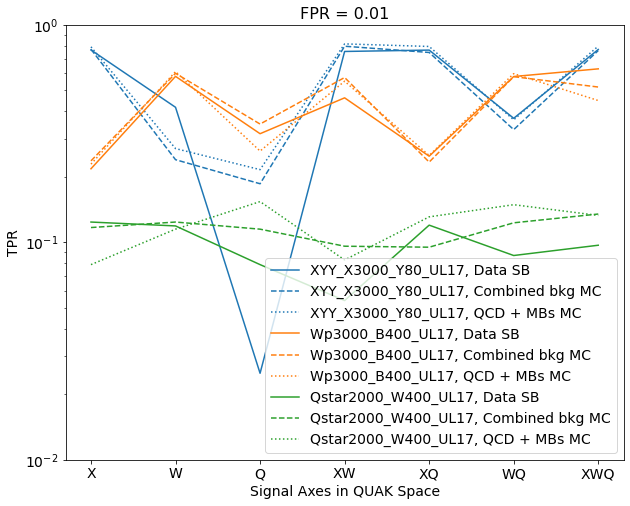

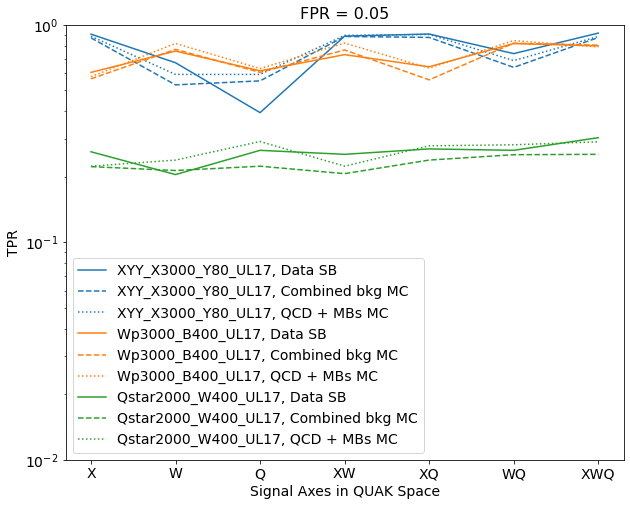

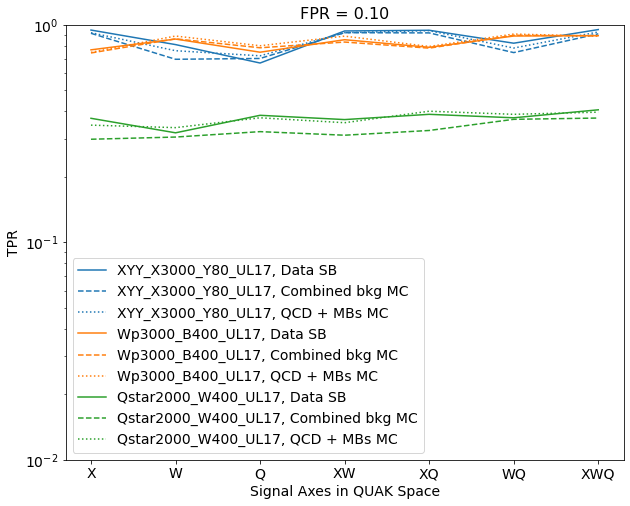

In [5]:
for f in fprs:
    plt.figure(figsize=(10,8))
    xvals = np.arange(len(axisSets))
    sig_fprtpr_curves_sb = {s:[] for s in sigs}
    sig_fprtpr_curves_mc = {s:[] for s in sigs}
    sig_fprtpr_curves_mb = {s:[] for s in sigs}
    for i,axSet in enumerate(axisSets):
        fpr_tpr_dict_sb = fpr_tpr_total_sb[axSet]
        fpr_tpr_dict_mc = fpr_tpr_total_mc[axSet]
        fpr_tpr_dict_mb = fpr_tpr_total_mb[axSet]
        for s in sigs:
            d_sb = fpr_tpr_dict_sb[s]
            d_mc = fpr_tpr_dict_mc[s]
            d_mb = fpr_tpr_dict_mb[s]
            sig_fprtpr_curves_sb[s].append(d_sb[f])
            sig_fprtpr_curves_mc[s].append(d_mc[f])
            sig_fprtpr_curves_mb[s].append(d_mb[f])

    for i,s in enumerate(sigs):
        curv_sb = sig_fprtpr_curves_sb[s]
        curv_mc = sig_fprtpr_curves_mc[s]
        curv_mb = sig_fprtpr_curves_mb[s]
        plt.plot(xvals,curv_sb,label=s+", Data SB",linestyle='-',color='C{0}'.format(i))
        plt.plot(xvals,curv_mc,label=s+", Combined bkg MC",linestyle='--',color='C{0}'.format(i))
        plt.plot(xvals,curv_mb,label=s+", QCD + MBs MC",linestyle=':',color='C{0}'.format(i))
    plt.title("FPR = {0:.2f}".format(f),fontsize=16)

    plt.yscale('log')
    plt.ylim([0.01,1])
    plt.yticks(fontsize=14)
    plt.legend(loc='best',fontsize=14)
    plt.xticks(ticks=xvals,labels=axisSets,fontsize=14)
    plt.xlabel("Signal Axes in QUAK Space",fontsize=14)
    plt.ylabel("TPR",fontsize=14)
    plt.show()